# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import json

# Data Loading

In [ ]:
members = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/members.csv")
songs = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/songs.csv")
songs_extra = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/song_extra_info.csv")
train = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Music_Recom_ML/test.csv")

# Merging Datasets

In [ ]:
train_df = train.merge(songs, on='song_id', how='left')
train_df = train_df.merge(songs_extra, on='song_id', how='left')
train_df = train_df.merge(members, on='msno', how='left')

In [ ]:
test_df = test.merge(songs, on='song_id', how='left')
test_df = test_df.merge(songs_extra, on='song_id', how='left')
test_df = test_df.merge(members, on='msno', how='left')

# Data Cleaning - Train

<Axes: >

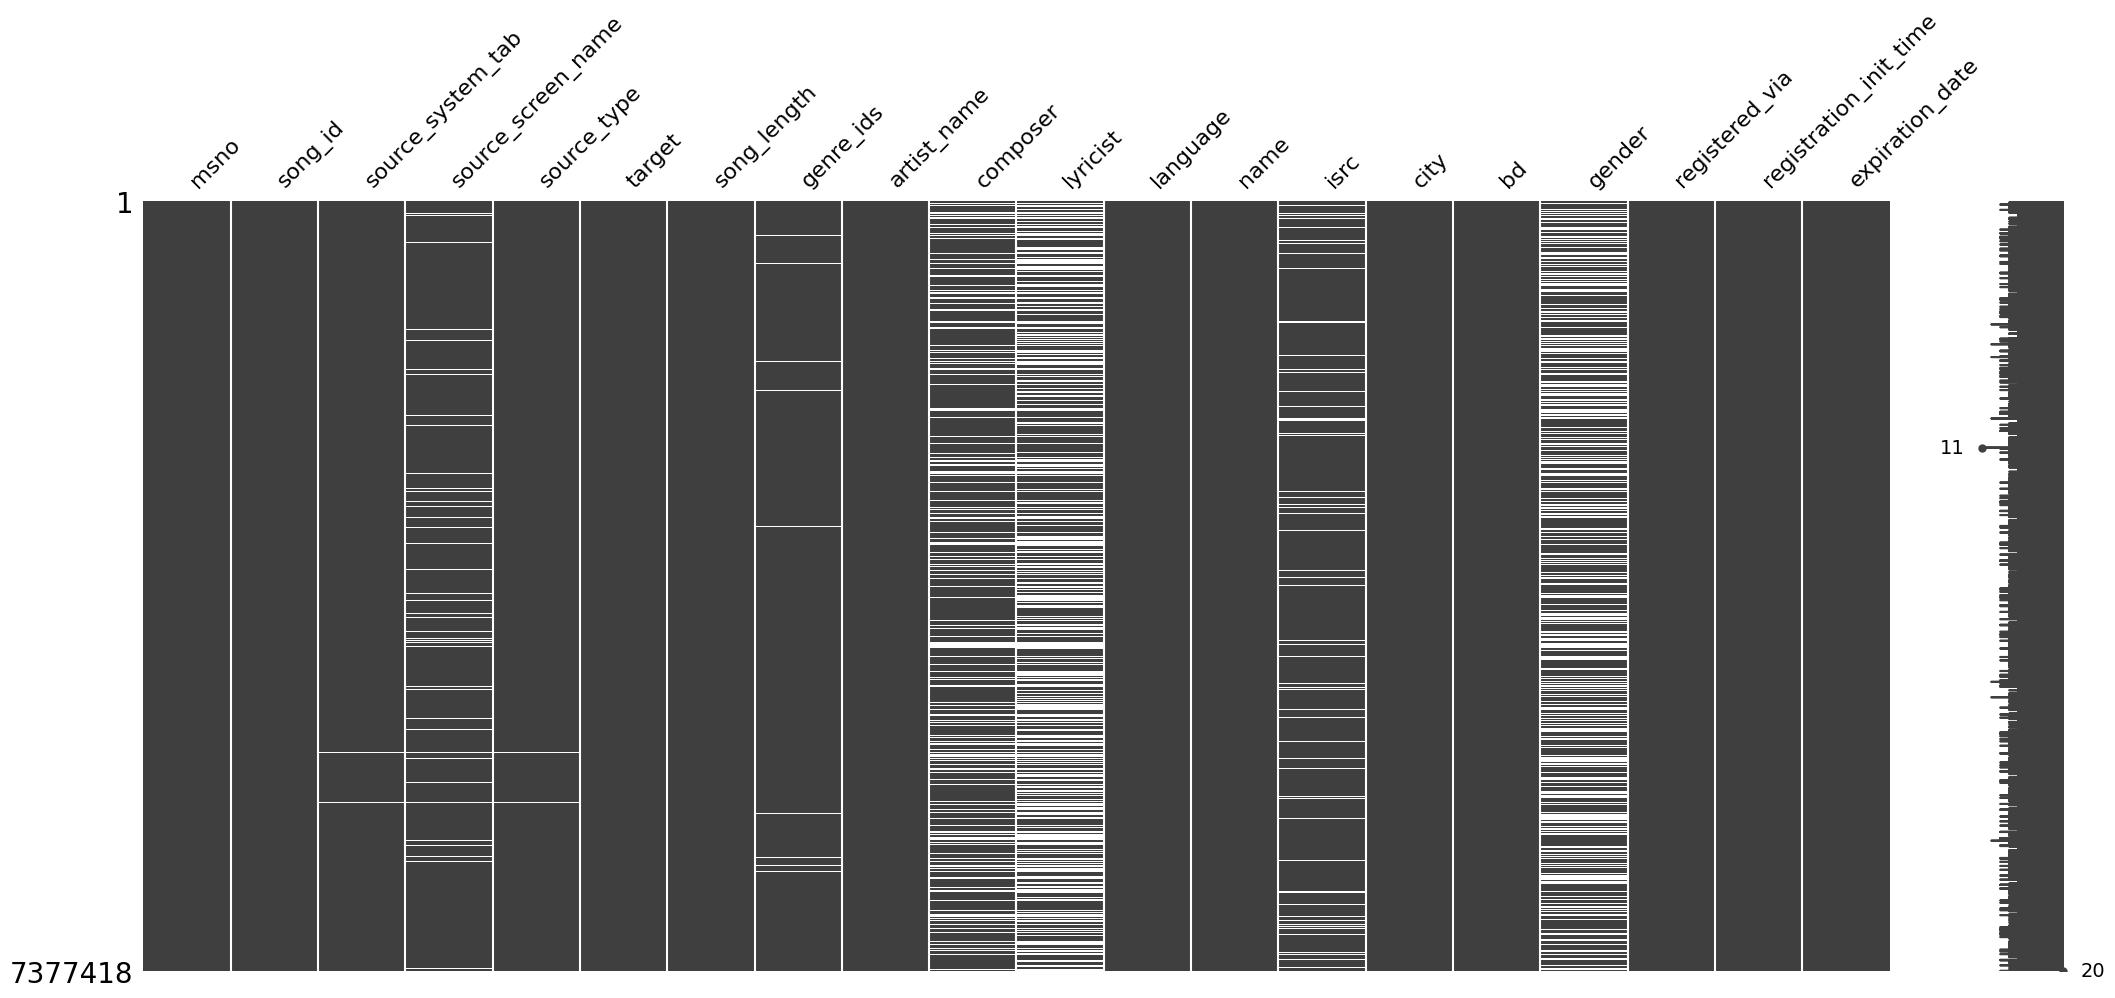

In [ ]:
msno.matrix(train_df)

In [ ]:
cols = ["source_system_tab", "source_screen_name", "source_type", "gender", "isrc", "artist_name", "composer", "lyricist", "genre_ids"]
med_cols = ["song_length", "bd"]
med_vals_train = {}

# Set to Unknown
for col in cols:
  train_df[col] = train_df[col].fillna("Unknown")

train_df["name"] = train_df["name"].fillna("Unknown_song")
train_df["language"] = train_df["language"].fillna(-1)

# Removing Unrealistic Age Values
train_df["bd"] = train_df["bd"].apply(lambda x: x if 10 < x < 80 else np.nan)

# Set to Median
for col in med_cols:
  train_df[col] = train_df[col].fillna(train_df[col].median())
  med_vals_train[col] = train_df[col].median()

<Axes: >

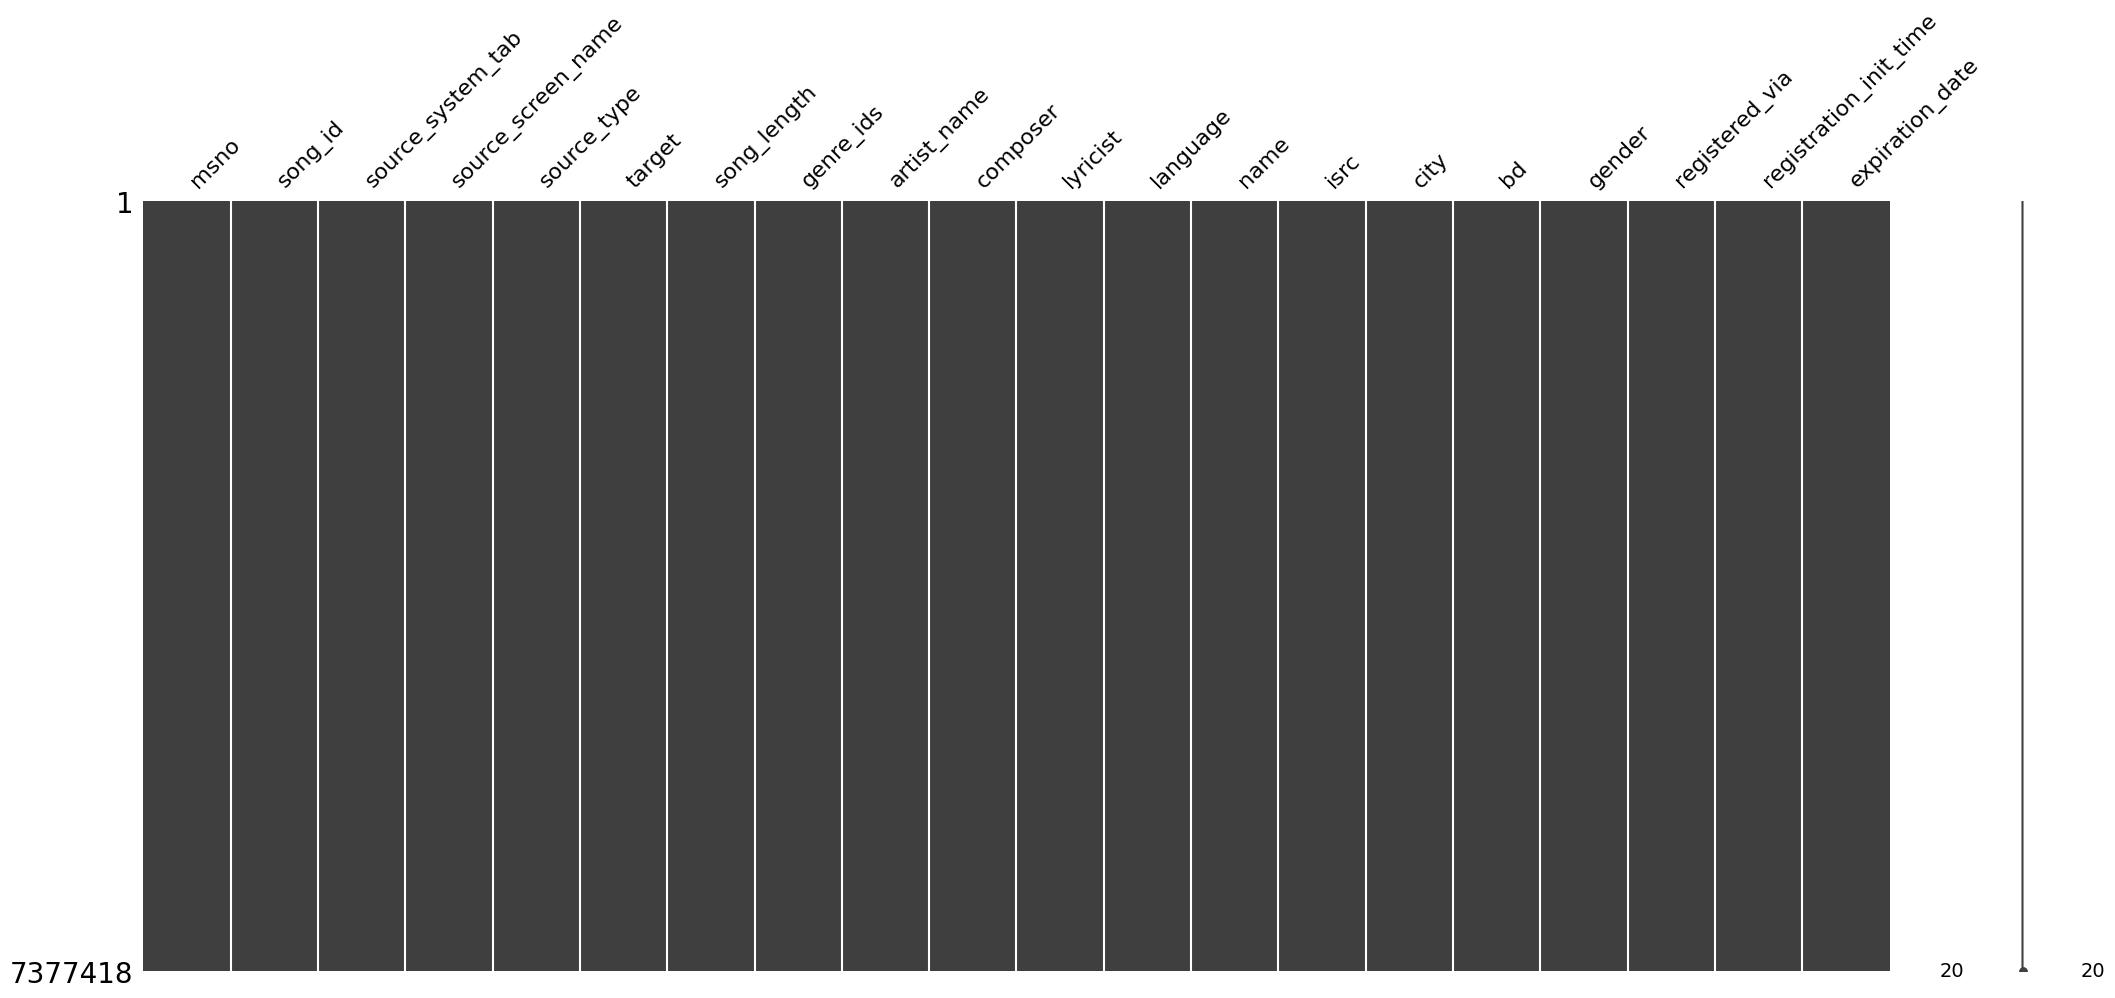

In [ ]:
msno.matrix(train_df)

# Data Cleaning - Test

<Axes: >

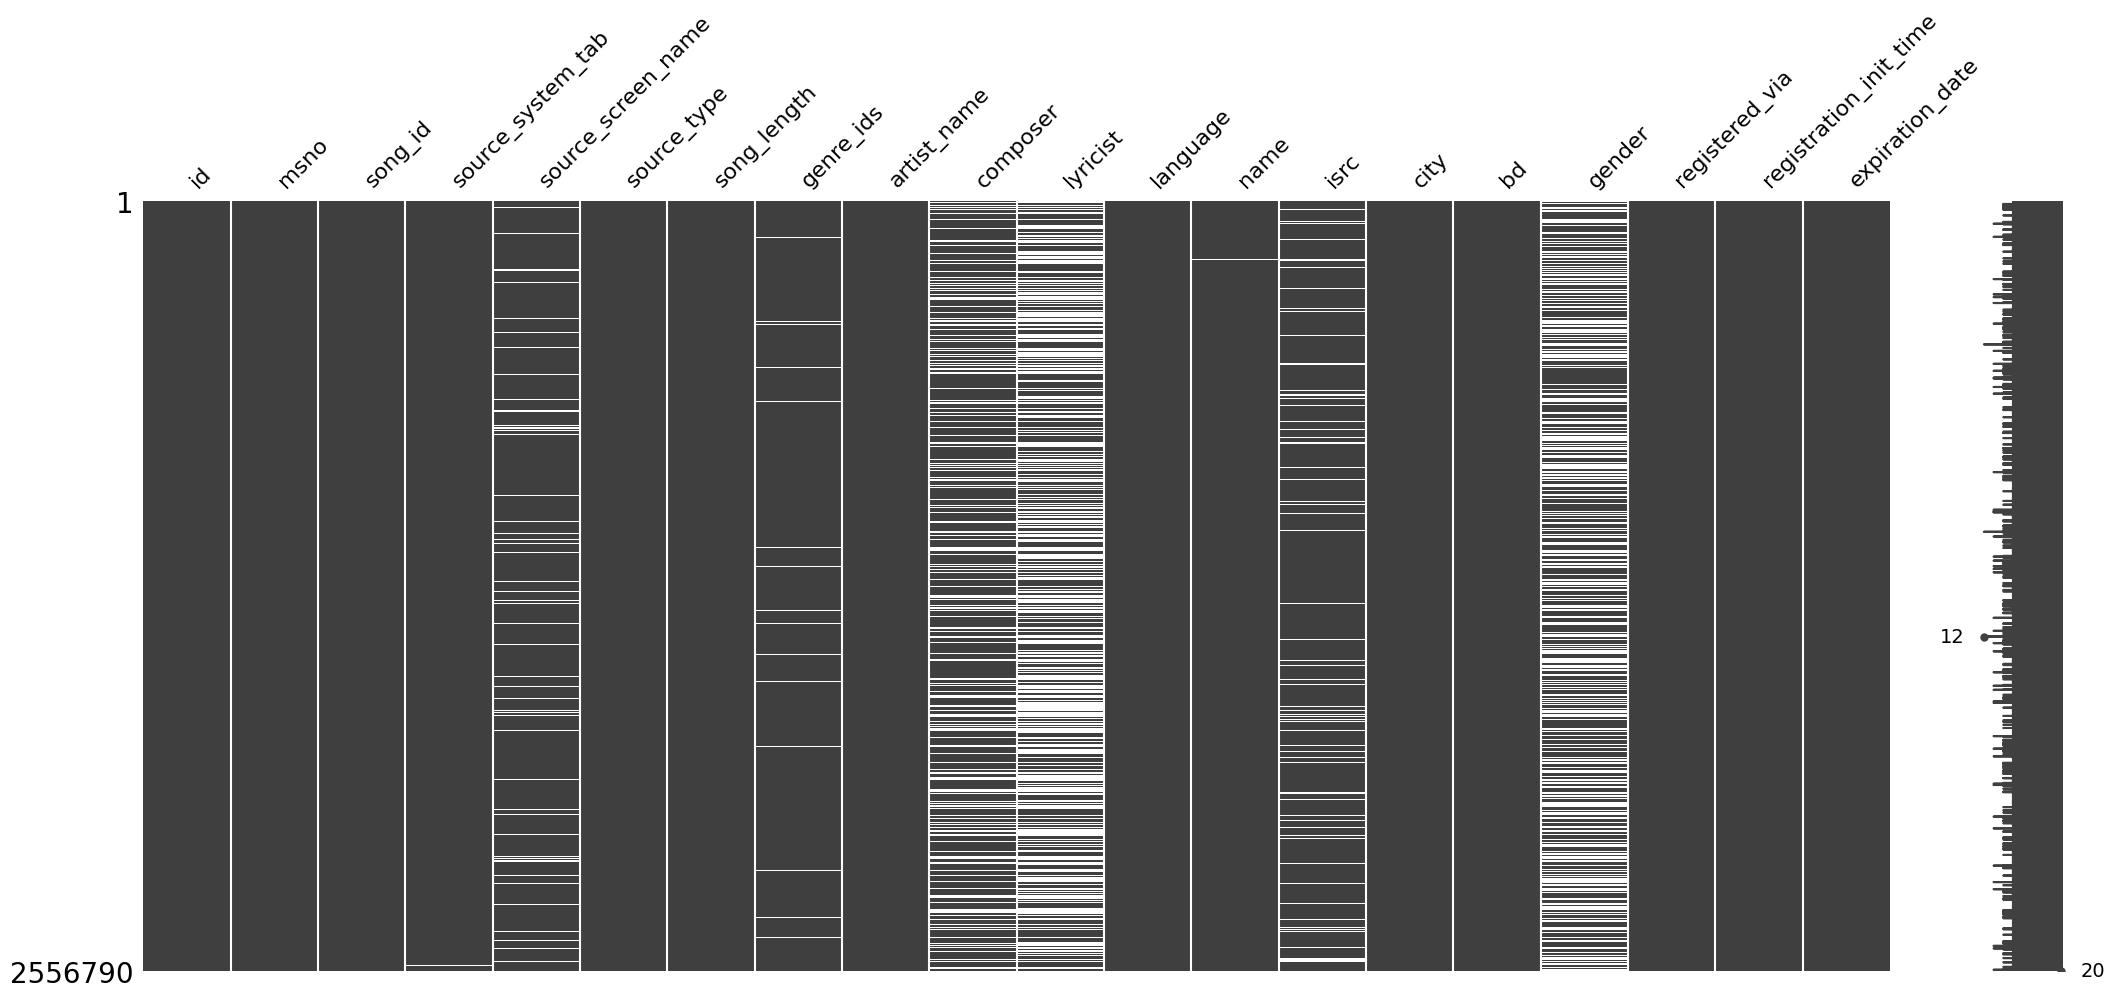

In [ ]:
msno.matrix(test_df)

In [ ]:
# Set to Unknown
for col in cols:
  test_df[col] = test_df[col].fillna("Unknown")

test_df["name"] = test_df["name"].fillna("Unknown_song")
test_df["language"] = test_df["language"].fillna(-1)

# Removing Unrealistic Age Values
test_df["bd"] = test_df["bd"].apply(lambda x: x if 10 < x < 80 else np.nan)

# Set to Median
for col in med_cols:
  test_df[col] = test_df[col].fillna(med_vals_train[col])

<Axes: >

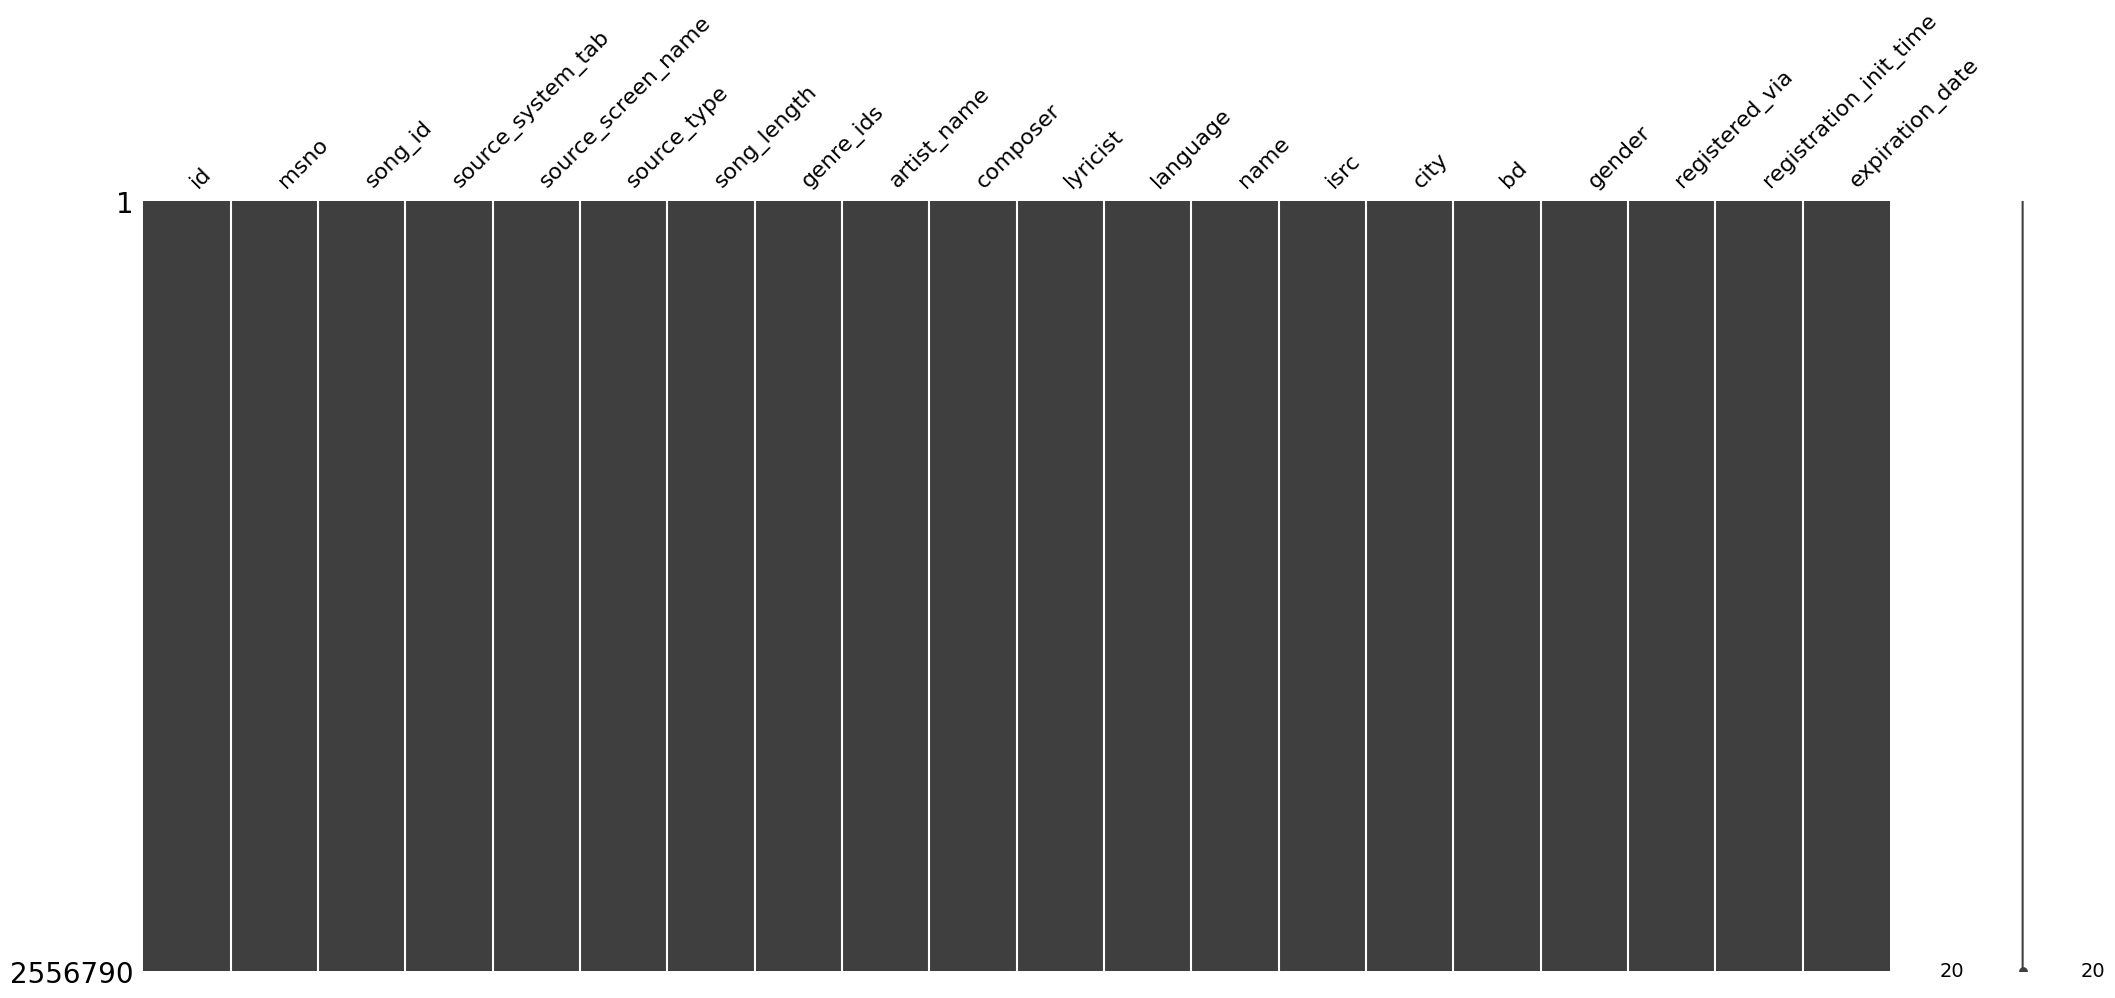

In [ ]:
msno.matrix(test_df)

# Feature Engineering - Train

In [ ]:
# Modifying Existing Columns
train_df["registration_init_time"] = pd.to_datetime(train_df["registration_init_time"], format="%Y%m%d")
train_df["expiration_date"] = pd.to_datetime(train_df["expiration_date"], format="%Y%m%d")

# Creating New Columns
train_df["song_length_min"] = train_df["song_length"]/60000

train_df["age_group"] = pd.cut(train_df["bd"], bins=[0,18,25,35,50,100], labels=[0,1,2,3,4])
train_df["is_young_user"] = (train_df["bd"] < 25).astype(int)

train_df["reg_year"] = train_df["registration_init_time"].dt.year
train_df["reg_month"] = train_df["registration_init_time"].dt.month

train_df["exp_year"] = train_df["expiration_date"].dt.year
train_df["exp_month"] = train_df["expiration_date"].dt.month

train_df["membership_days"] = (train_df["expiration_date"] - train_df["registration_init_time"]).dt.days
train_df["account_age_days"] = (pd.Timestamp("today") - train_df["registration_init_time"]).dt.days

train_df["isrc_country"] = train_df["isrc"].apply(lambda x: x[:2] if x!="Unknown" else "Unknown")
train_df["isrc_year"] = train_df["isrc"].apply(lambda x: int(x[5:7]) if x!="Unknown" else -1)

train_df["artist_count"] = train_df["artist_name"].apply(lambda x: len(str(x).split("|")))
train_df["composer_count"] = train_df["composer"].apply(lambda x: len(str(x).split("|")))
train_df["lyricist_count"] = train_df["lyricist"].apply(lambda x: len(str(x).split("|")))

train_df["genre_count"] = train_df["genre_ids"].apply(lambda x: len(str(x).split("|")))
train_df["primary_genre"] = train_df["genre_ids"].apply(lambda x: str(x).split("|")[0])

train_df["song_name_length"] = train_df["name"].apply(lambda x: len(str(x)))

In [ ]:
user_song_count = train_df.groupby("msno")["song_id"].count().reset_index()
user_song_count.columns = ["msno", "user_song_count"]
train_df = train_df.merge(user_song_count, on="msno", how="left")

song_play_count = train_df.groupby("song_id")["msno"].count().reset_index()
song_play_count.columns = ["song_id", "song_play_count"]
train_df = train_df.merge(song_play_count, on="song_id", how="left")

user_unique_songs = train_df.groupby("msno")["song_id"].nunique().reset_index()
user_unique_songs.columns = ["msno", "user_unique_songs"]
train_df = train_df.merge(user_unique_songs, on="msno", how="left")

song_user_count = train_df.groupby("song_id")["msno"].nunique().reset_index()
song_user_count.columns = ["song_id", "song_user_count"]
train_df = train_df.merge(song_user_count, on="song_id", how="left")

user_unique_artists = train_df.groupby("msno")["artist_name"].nunique().reset_index()
user_unique_artists.columns = ["msno", "user_unique_artists"]
train_df = train_df.merge(user_unique_artists, on="msno", how="left")

artist_song_count = train_df.groupby("artist_name")["song_id"].nunique().reset_index()
artist_song_count.columns = ["artist_name", "artist_song_count"]
train_df = train_df.merge(artist_song_count, on="artist_name", how="left")

artist_popularity = train_df["artist_name"].value_counts().reset_index()
artist_popularity.columns = ["artist_name", "artist_popularity"]
train_df = train_df.merge(artist_popularity, on="artist_name", how="left")

Dropping a few columns



In [ ]:
train_df.drop(columns=["msno", "song_id", "name", "isrc", "expiration_date", "registration_init_time", "genre_ids", "artist_name", "composer", "lyricist"], inplace=True)

In [ ]:
train_df.to_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/train_features_v1.parquet", index=False)

# Feature Engineering - Test

In [ ]:
# Modifying Existing Columns
test_df["registration_init_time"] = pd.to_datetime(test_df["registration_init_time"], format="%Y%m%d")
test_df["expiration_date"] = pd.to_datetime(test_df["expiration_date"], format="%Y%m%d")

# Creating New Columns
test_df["song_length_min"] = test_df["song_length"]/60000

test_df["age_group"] = pd.cut(test_df["bd"], bins=[0,18,25,35,50,100], labels=[0,1,2,3,4])
test_df["is_young_user"] = (test_df["bd"] < 25).astype(int)

test_df["reg_year"] = test_df["registration_init_time"].dt.year
test_df["reg_month"] = test_df["registration_init_time"].dt.month

test_df["exp_year"] = test_df["expiration_date"].dt.year
test_df["exp_month"] = test_df["expiration_date"].dt.month

test_df["membership_days"] = (test_df["expiration_date"] - test_df["registration_init_time"]).dt.days
test_df["account_age_days"] = (pd.Timestamp("today") - test_df["registration_init_time"]).dt.days

test_df["isrc_country"] = test_df["isrc"].apply(lambda x: x[:2] if x!="Unknown" else "Unknown")
test_df["isrc_year"] = test_df["isrc"].apply(lambda x: int(x[5:7]) if x!="Unknown" else -1)

test_df["artist_count"] = test_df["artist_name"].apply(lambda x: len(str(x).split("|")))
test_df["composer_count"] = test_df["composer"].apply(lambda x: len(str(x).split("|")))
test_df["lyricist_count"] = test_df["lyricist"].apply(lambda x: len(str(x).split("|")))

test_df["genre_count"] = test_df["genre_ids"].apply(lambda x: len(str(x).split("|")))
test_df["primary_genre"] = test_df["genre_ids"].apply(lambda x: str(x).split("|")[0])

test_df["song_name_length"] = test_df["name"].apply(lambda x: len(str(x)))

In [ ]:
test_df = test_df.merge(user_song_count, on="msno", how="left")

test_df = test_df.merge(song_play_count, on="song_id", how="left")

test_df = test_df.merge(user_unique_songs, on="msno", how="left")

test_df = test_df.merge(song_user_count, on="song_id", how="left")

test_df = test_df.merge(user_unique_artists, on="msno", how="left")

test_df = test_df.merge(artist_song_count, on="artist_name", how="left")

test_df = test_df.merge(artist_popularity, on="artist_name", how="left")

Dropping a few columns

In [ ]:
test_df.drop(columns=["id", "msno", "song_id", "name", "isrc", "expiration_date", "registration_init_time", "genre_ids", "artist_name", "composer", "lyricist"], inplace=True)

Fixing Null values after merge

In [ ]:
test_df["user_song_count"] = test_df["user_song_count"].fillna(0)
test_df["song_play_count"] = test_df["song_play_count"].fillna(0)
test_df["user_unique_songs"] = test_df["user_unique_songs"].fillna(0)
test_df["song_user_count"] = test_df["song_user_count"].fillna(0)
test_df["user_unique_artists"] = test_df["user_unique_artists"].fillna(0)
test_df["artist_song_count"] = test_df["artist_song_count"].fillna(0)
test_df["artist_popularity"] = test_df["artist_popularity"].fillna(0)

In [ ]:
test_df.to_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/test_features_v1.parquet", index=False)

# Label Encoding

In [ ]:
train_df = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/train_features_v1.parquet")
test_df = pd.read_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/test_features_v1.parquet")

In [ ]:
cat_cols = ["source_system_tab", "source_screen_name", "source_type", "gender", "age_group", "isrc_country", "primary_genre"]

for col in cat_cols:

    le = LabelEncoder()

    combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)

    le.fit(combined)

    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

In [ ]:
X = train_df.drop("target", axis=1)
y = train_df["target"]

Make sure columns match

In [ ]:
test_df = test_df[X.columns]

for col in X.columns:
  if(test_df[col].dtype != X[col].dtype):
    test_df[col] = test_df[col].astype(X[col].dtype)

In [ ]:
print((X.columns == test_df.columns).all())

True


# Train Test Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
X_train.to_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/X_train.parquet", index=False)
X_val.to_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/X_val.parquet", index=False)

y_train.to_frame().to_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/y_train.parquet", index=False)
y_val.to_frame().to_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/y_val.parquet", index=False)

test_df.to_parquet("/content/drive/MyDrive/Music_Recom_ML/Processed/test_encoded.parquet", index=False)

In [ ]:
features = list(X_train.columns)

with open("/content/drive/MyDrive/Music_Recom_ML/Processed/features.json","w") as f:
    json.dump(features,f)